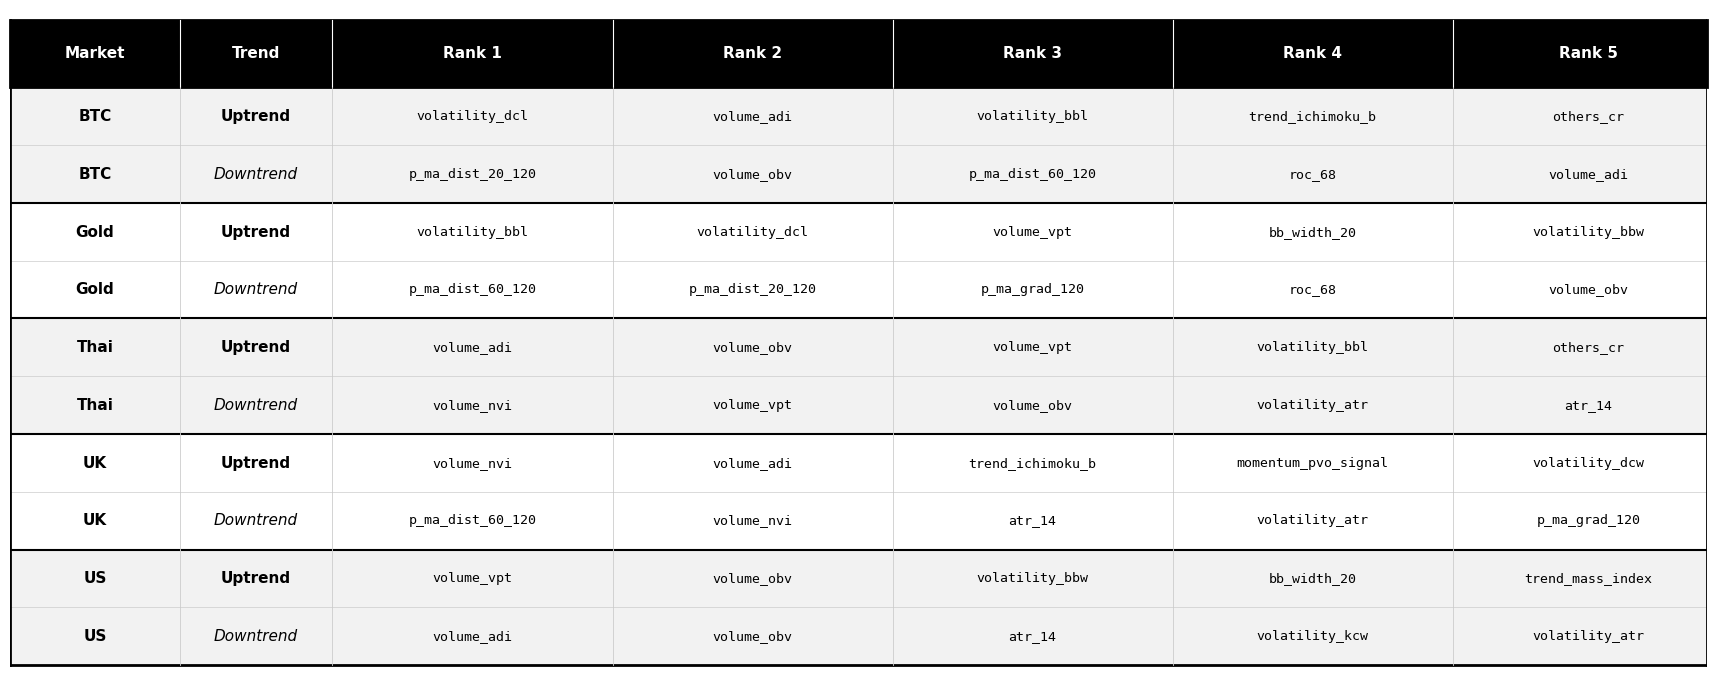

Saved → /Users/oattao/project/p-e/ipynb/image/table3_feature_importance.png


In [1]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

# ─── Data ────────────────────────────────────────────────────────
col_headers = ['Market', 'Trend', 'Rank 1', 'Rank 2', 'Rank 3', 'Rank 4', 'Rank 5']
col_widths  = [0.10, 0.09, 0.165, 0.165, 0.165, 0.165, 0.16]

rows = [
    ['BTC',  'Uptrend',   'volatility_dcl',      'volume_adi',       'volatility_bbl',    'trend_ichimoku_b',    'others_cr'],
    ['BTC',  'Downtrend', 'p_ma_dist_20_120',    'volume_obv',       'p_ma_dist_60_120',  'roc_68',              'volume_adi'],
    ['Gold', 'Uptrend',   'volatility_bbl',      'volatility_dcl',   'volume_vpt',        'bb_width_20',         'volatility_bbw'],
    ['Gold', 'Downtrend', 'p_ma_dist_60_120',    'p_ma_dist_20_120', 'p_ma_grad_120',     'roc_68',              'volume_obv'],
    ['Thai', 'Uptrend',   'volume_adi',          'volume_obv',       'volume_vpt',        'volatility_bbl',      'others_cr'],
    ['Thai', 'Downtrend', 'volume_nvi',          'volume_vpt',       'volume_obv',        'volatility_atr',      'atr_14'],
    ['UK',   'Uptrend',   'volume_nvi',          'volume_adi',       'trend_ichimoku_b',  'momentum_pvo_signal', 'volatility_dcw'],
    ['UK',   'Downtrend', 'p_ma_dist_60_120',    'volume_nvi',       'atr_14',            'volatility_atr',      'p_ma_grad_120'],
    ['US',   'Uptrend',   'volume_vpt',          'volume_obv',       'volatility_bbw',    'bb_width_20',         'trend_mass_index'],
    ['US',   'Downtrend', 'volume_adi',          'volume_obv',       'atr_14',            'volatility_kcw',      'volatility_atr'],
]

# ─── Layout ──────────────────────────────────────────────────────
ROW_H    = 0.58
HEADER_H = 0.68
FIG_W    = 17.0
N_ROWS   = len(rows)
FIG_H    = HEADER_H + N_ROWS * ROW_H + 0.20

BLACK = '#000000'
WHITE = '#ffffff'
GRAY  = '#f2f2f2'
LGRAY = '#cccccc'

market_bg = {
    'BTC':  GRAY,
    'Gold': WHITE,
    'Thai': GRAY,
    'UK':   WHITE,
    'US':   GRAY,
}

matplotlib.rcParams['font.family'] = ['DejaVu Sans']
fig, ax = plt.subplots(figsize=(FIG_W, FIG_H))
ax.set_xlim(0, 1)
ax.set_ylim(0, FIG_H)
ax.axis('off')
fig.patch.set_facecolor(WHITE)

def cx(i):
    return sum(col_widths[:i])

# ── Header ────────────────────────────────────────────────────────
hdr_top = FIG_H - 0.10
hdr_bot = hdr_top - HEADER_H

ax.add_patch(mpatches.FancyBboxPatch(
    (0, hdr_bot), 1, HEADER_H,
    boxstyle='square,pad=0', facecolor=BLACK, edgecolor=BLACK,
    linewidth=2, clip_on=False))

for ci, (label, w) in enumerate(zip(col_headers, col_widths)):
    if ci > 0:
        ax.plot([cx(ci), cx(ci)], [hdr_bot, hdr_top],
                color=WHITE, linewidth=0.8, zorder=5)
    ax.text(cx(ci) + w / 2, (hdr_top + hdr_bot) / 2, label,
            ha='center', va='center',
            fontsize=11, fontweight='bold', color=WHITE)

ax.plot([0, 1], [hdr_bot, hdr_bot], color=BLACK, linewidth=2)

# ── Rows ──────────────────────────────────────────────────────────
prev_market = None
for ri, row_data in enumerate(rows):
    ry0 = hdr_bot - ri * ROW_H
    ry1 = ry0 - ROW_H
    market = row_data[0]

    ax.add_patch(mpatches.FancyBboxPatch(
        (0, ry1), 1, ROW_H,
        boxstyle='square,pad=0', facecolor=market_bg[market],
        edgecolor='none', clip_on=False))

    is_new = (market != prev_market)
    ax.plot([0, 1], [ry0, ry0],
            color=BLACK if is_new else LGRAY,
            linewidth=1.5 if is_new else 0.5)

    for ci, (val, w) in enumerate(zip(row_data, col_widths)):
        if ci > 0:
            ax.plot([cx(ci), cx(ci)], [ry1, ry0],
                    color=LGRAY, linewidth=0.6, zorder=5)

        # Style per column
        if ci == 0:                          # Market — bold
            fw, fs, fst = 'bold', 11, 'normal'
        elif ci == 1:                        # Trend
            fw  = 'bold' if val == 'Uptrend' else 'normal'
            fs  = 11
            fst = 'normal' if val == 'Uptrend' else 'italic'
        else:                                # Feature names — monospace style
            fw, fs, fst = 'normal', 9.5, 'normal'

        ax.text(cx(ci) + w / 2, (ry0 + ry1) / 2, val,
                ha='center', va='center',
                fontsize=fs, fontweight=fw, fontstyle=fst,
                color=BLACK, fontfamily='monospace' if ci >= 2 else 'DejaVu Sans')

    prev_market = market

# ── Border ───────────────────────────────────────────────────────
bot = hdr_bot - N_ROWS * ROW_H
ax.plot([0, 1], [bot, bot], color=BLACK, linewidth=2)
ax.plot([0, 0], [bot, hdr_top], color=BLACK, linewidth=2)
ax.plot([1, 1], [bot, hdr_top], color=BLACK, linewidth=2)

# ── Save ─────────────────────────────────────────────────────────
out_dir  = '/Users/oattao/project/p-e/ipynb/image'
os.makedirs(out_dir, exist_ok=True)
out_path = os.path.join(out_dir, 'table3_feature_importance.png')

plt.tight_layout(pad=0.1)
plt.savefig(out_path, dpi=200, bbox_inches='tight',
            facecolor=WHITE, pad_inches=0.12)
plt.show()
print(f'Saved → {out_path}')